# 04. OLTW: On-Line Time Warping

Самый простой из наших трекеров и **исторически первый** в репо. Алгоритм Dixon 2005 [3]: онлайн-вариант DTW (Dynamic Time Warping). Не вероятностный, нет распределений — просто матрица стоимостей и поиск пути.

## Что делает

На каждое входное событие `(pitch, timestamp)`:

1. Считает локальную стоимость для каждого score-state: `local_cost[i] = |pitch - score_pitch[i]|`, обрезанную сверху `max_local_cost`.
2. Обновляет одну колонку матрицы накопленных стоимостей. Хранит только две колонки в памяти.
3. Берёт `argmin` текущей колонки — это и есть предсказанный score-state.
4. Монотонизация: не позволяет позиции откатиться назад.
5. RunCount fail-safe: если позиция не двигается слишком долго (`max_run` подряд событий), принудительно сдвигает вперёд.

## Чего нет

- Нет распределения по позициям, есть только одна гипотеза.
- Не учитывает длительности (только последовательность pitch).
- Не имеет confidence — выход всегда «жёсткий» индекс.

Используется как **резервный** трекер в `HybridScoreFollower`: когда HMM теряется (низкая confidence), управление переходит на OLTW.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import numpy as np
import matplotlib.pyplot as plt

from musictech.core import ScoreFollowerOLTW
from dataset_viewer import load_performance

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

DATA = PROJECT_ROOT / "generated_dataset"

pygame-ce 2.5.7 (SDL 2.32.10, Python 3.12.4)


## 1. Сценарий «ideal»: трекер должен идти строго 0 → 7

Каждое событие чисто соответствует одному state. OLTW обязан выдавать `predicted == event_index`.

In [2]:
def run_oltw(score_path: Path, perf_path: Path):
    follower = ScoreFollowerOLTW(str(score_path))
    performance = load_performance(perf_path)
    predicted = []
    for event in performance:
        idx = follower.process_event(event["pitch"], event["timestamp"])
        predicted.append(idx)
    return follower, performance, predicted

follower, performance, predicted = run_oltw(DATA / "ideal.json", DATA / "ideal.mid")
print("Score length :", follower.N)
print("Events       :", len(performance))
print("Predicted    :", predicted)
print("Expected     :", list(range(follower.N)))

Score length : 8
Events       : 8
Predicted    : [0, 1, 2, 3, 4, 5, 6, 7]
Expected     : [0, 1, 2, 3, 4, 5, 6, 7]


## 2. Сценарий «rubato»: тот же набор нот, разные интервалы

OLTW обязан тоже всё угадать, потому что pitch последовательность не изменилась. Распределение по времени для DTW не имеет значения — только порядок и pitch.

In [3]:
follower, performance, predicted = run_oltw(DATA / "rubato.json", DATA / "rubato.mid")
print("Predicted:", predicted)
print("Expected :", list(range(follower.N)))

Predicted: [0, 1, 2, 3, 4, 5, 6, 7]
Expected : [0, 1, 2, 3, 4, 5, 6, 7]


## 3. Сценарий «noisy»: лишние и неправильные ноты

Здесь интереснее: в исполнении встречаются ноты, которых нет в партитуре (insertions) и пропущенные ноты (deletions). OLTW должен **остаться на месте** на лишних нотах и **перепрыгнуть** при пропусках.

In [4]:
follower, performance, predicted = run_oltw(DATA / "noisy.json", DATA / "noisy.mid")
for i, (event, p) in enumerate(zip(performance, predicted)):
    print(
        f"#{i:2d} pitch={event['pitch']:>3} t={event['timestamp']:.3f} "
        f"-> predicted_index={p} (score_pitch={int(follower.pitches[p])})"
    )

# 0 pitch= 59 t=0.000 -> predicted_index=0 (score_pitch=60)
# 1 pitch= 59 t=0.120 -> predicted_index=0 (score_pitch=60)
# 2 pitch= 62 t=0.620 -> predicted_index=1 (score_pitch=62)
# 3 pitch= 70 t=0.720 -> predicted_index=1 (score_pitch=62)
# 4 pitch= 62 t=0.840 -> predicted_index=1 (score_pitch=62)
# 5 pitch= 69 t=1.340 -> predicted_index=2 (score_pitch=64)
# 6 pitch= 66 t=1.459 -> predicted_index=3 (score_pitch=65)
# 7 pitch= 66 t=1.959 -> predicted_index=3 (score_pitch=65)
# 8 pitch= 66 t=2.079 -> predicted_index=3 (score_pitch=65)
# 9 pitch= 68 t=2.579 -> predicted_index=4 (score_pitch=67)
#10 pitch= 62 t=3.079 -> predicted_index=4 (score_pitch=67)
#11 pitch= 64 t=3.179 -> predicted_index=4 (score_pitch=67)
#12 pitch= 72 t=3.299 -> predicted_index=4 (score_pitch=67)
#13 pitch= 62 t=3.799 -> predicted_index=5 (score_pitch=69)


## 4. График предсказанной траектории

Идеальная траектория — это диагональ (event_index, score_index) = (i, i).

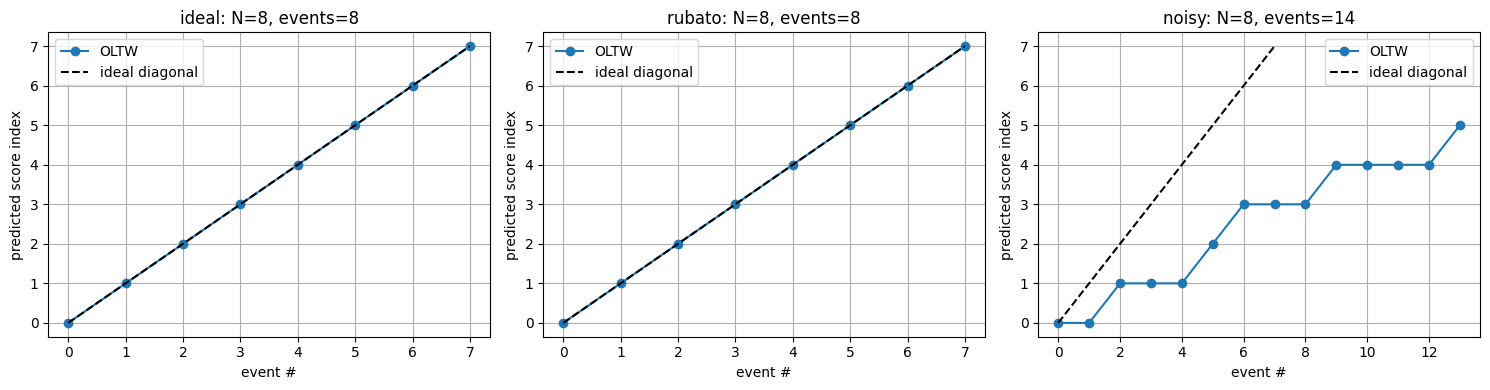

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, ["ideal", "rubato", "noisy"]):
    follower, performance, predicted = run_oltw(DATA / f"{name}.json", DATA / f"{name}.mid")
    ax.plot(predicted, marker="o", label="OLTW")
    ax.plot(np.arange(min(len(predicted), follower.N)), linestyle="--", color="black", label="ideal diagonal")
    ax.set_title(f"{name}: N={follower.N}, events={len(performance)}")
    ax.set_xlabel("event #")
    ax.set_ylabel("predicted score index")
    ax.legend()
plt.tight_layout()
plt.show()

## 5. Что важно для тезисов

- **OLTW даёт всегда жёсткий ответ** без распределения. Это не подходит как вход для RL-агента: тезисы требуют `α̂_t` — сжатое апостериорное распределение из HMM/HSMM.
- **OLTW устойчив к rubato и шуму на коротких пьесах**, но плохо переносит структурные ошибки (повторы, скачки в скрипте). В гибриде он используется как fallback и для якорной разметки.
- **Внутри OLTW** доступны `follower.prev_col`, `follower.curr_col` — две колонки DTW. Их можно визуализировать для отладки (предлагается как задание читателю; быстро становится тяжело смотреть при N>50).